In [1]:
import kagglehub
import os 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

# Download latest version
path = kagglehub.dataset_download("urvishahir/global-freelancers-raw-dataset")

print("Path to dataset files:", path)


print(os.listdir(path))

Path to dataset files: C:\Users\ALOK\.cache\kagglehub\datasets\urvishahir\global-freelancers-raw-dataset\versions\1
['global_freelancers_raw.csv']


In [2]:
df=pd.read_csv(path+"/global_freelancers_raw.csv")
df

,freelancer_ID,name,gender,age,country,language,primary_skill,years_of_experience,hourly_rate (USD),rating,is_active,client_satisfaction
0,FL250001,Ms. Nicole Kidd,f,52.0,Italy,Italian,Blockchain Development,11.0,100,NaN,0,NaN
1,FL250002,Vanessa Garcia,FEMALE,52.0,Australia,English,Mobile Apps,34.0,USD 100,3.3,1,84%
2,FL250003,Juan Nelson,male,53.0,Germany,German,Graphic Design,31.0,50,0.0,N,71%
3,FL250004,Amanda Spencer,F,38.0,Australia,English,Web Development,4.0,$40,1.5,N,90%
4,FL250005,Lynn Curtis DDS,female,53.0,Germany,German,Web Development,27.0,30,4.8,0,83%
...,...,...,...,...,...,...,...,...,...,...,...,...
995,FL250996,Albert Wilcox,Male,56.0,Turkey,Turkish,DevOps,13.0,100,0.0,no,68%
996,FL250997,Cheryl Norris,f,26.0,Germany,German,Blockchain Development,6.0,USD 40,2.8,N,82
997,FL250998,Kathy Watkins,female,37.0,Japan,Japanese,Data Analysis,15.0,75,NaN,False,94%
998,FL250999,John Obrien,m,46.0,Russia,Russian,Machine Learning,22.0,100,2.8,yes,97


In [3]:
for i in df:
    print(i,df[i].unique())

freelancer_ID ['FL250001' 'FL250002' 'FL250003' 'FL250004' 'FL250005' 'FL250006'
 'FL250007' 'FL250008' 'FL250009' 'FL250010' 'FL250011' 'FL250012'
 'FL250013' 'FL250014' 'FL250015' 'FL250016' 'FL250017' 'FL250018'
 'FL250019' 'FL250020' 'FL250021' 'FL250022' 'FL250023' 'FL250024'
 'FL250025' 'FL250026' 'FL250027' 'FL250028' 'FL250029' 'FL250030'
 'FL250031' 'FL250032' 'FL250033' 'FL250034' 'FL250035' 'FL250036'
 'FL250037' 'FL250038' 'FL250039' 'FL250040' 'FL250041' 'FL250042'
 'FL250043' 'FL250044' 'FL250045' 'FL250046' 'FL250047' 'FL250048'
 'FL250049' 'FL250050' 'FL250051' 'FL250052' 'FL250053' 'FL250054'
 'FL250055' 'FL250056' 'FL250057' 'FL250058' 'FL250059' 'FL250060'
 'FL250061' 'FL250062' 'FL250063' 'FL250064' 'FL250065' 'FL250066'
 'FL250067' 'FL250068' 'FL250069' 'FL250070' 'FL250071' 'FL250072'
 'FL250073' 'FL250074' 'FL250075' 'FL250076' 'FL250077' 'FL250078'
 'FL250079' 'FL250080' 'FL250081' 'FL250082' 'FL250083' 'FL250084'
 'FL250085' 'FL250086' 'FL250087' 'FL250088' 'FL

In [4]:
df.dtypes

freelancer_ID           object
name                    object
gender                  object
age                    float64
country                 object
language                object
primary_skill           object
years_of_experience    float64
hourly_rate (USD)       object
rating                 float64
is_active               object
client_satisfaction     object
dtype: object

In [5]:
df.isnull().sum()

freelancer_ID            0
name                     0
gender                   0
age                     30
country                  0
language                 0
primary_skill            0
years_of_experience     51
hourly_rate (USD)       94
rating                 101
is_active               89
client_satisfaction    176
dtype: int64

In [6]:
df.describe()

,age,years_of_experience,rating
count,970.000000,949.000000,899.000000
mean,40.509278,11.340358,2.512570
std,11.942605,9.680610,1.546599
min,20.000000,0.000000,0.000000
25%,31.000000,3.000000,1.400000
50%,41.000000,9.000000,2.600000
75%,51.000000,17.000000,3.800000
max,60.000000,41.000000,5.000000


In [7]:
# DATA Cleaning for all columns 

In [8]:
df["is_active"]=df["is_active"].replace({"False":0,"True":1,"yes":1,"Y":1,np.NaN:0,"no":0,"N":0})
df["is_active"]=pd.to_numeric(df["is_active"])
df["is_active"].unique()

array([0, 1], dtype=int64)

In [9]:
df["gender"]=df["gender"].replace({"f":"F","male":"M","m":"M","MALE":"M","Female":"F","FEMALE":"F","Male":"M","female":"F"})
df["gender"].unique()

array(['F', 'M'], dtype=object)

In [10]:
df["years_of_experience"]=df["years_of_experience"].fillna(df["years_of_experience"].mean())
df["years_of_experience"].unique()

array([11.        , 34.        , 31.        ,  4.        , 27.        ,
       14.        , 10.        , 22.        , 17.        , 15.        ,
       18.        , 20.        ,  0.        , 13.        , 11.34035827,
        3.        ,  9.        , 21.        ,  8.        , 19.        ,
       32.        , 28.        ,  6.        , 23.        ,  7.        ,
        1.        , 33.        , 16.        , 35.        , 12.        ,
       38.        ,  5.        , 30.        ,  2.        , 25.        ,
       39.        , 29.        , 40.        , 26.        , 24.        ,
       37.        , 41.        ])

In [11]:
df["age"]=df["age"].fillna(df["age"].mean())
df["age"].unique()

array([52.        , 53.        , 38.        , 59.        , 43.        ,
       26.        , 40.        , 55.        , 57.        , 50.        ,
       42.        , 39.        , 56.        , 40.50927835, 51.        ,
       54.        , 22.        , 34.        , 36.        , 47.        ,
       41.        , 46.        , 29.        , 60.        , 21.        ,
       35.        , 25.        , 23.        , 31.        , 58.        ,
       45.        , 33.        , 32.        , 37.        , 49.        ,
       27.        , 48.        , 30.        , 20.        , 24.        ,
       44.        , 28.        ])

In [12]:
#cleaning client_satisfaction column 
df["client_satisfaction"]=df["client_satisfaction"].str.extract(r"(\d+)")
df["client_satisfaction"]=pd.to_numeric(df["client_satisfaction"])
df["client_satisfaction"]=df["client_satisfaction"].replace(np.nan,df["client_satisfaction"].mean())
df["client_satisfaction"].unique()

array([ 79.26941748,  84.        ,  71.        ,  90.        ,
        83.        ,  94.        ,  76.        ,  77.        ,
        86.        ,  93.        ,  70.        ,  69.        ,
        60.        ,  87.        ,  75.        ,  68.        ,
        65.        , 100.        ,  92.        ,  89.        ,
        62.        ,  82.        ,  81.        ,  63.        ,
        67.        ,  80.        ,  74.        ,  85.        ,
        79.        ,  72.        ,  64.        ,  88.        ,
        96.        ,  61.        ,  97.        ,  73.        ,
        78.        ,  95.        ,  66.        ,  91.        ,
        99.        ,  98.        ])

In [13]:
#cleaning hourly_rate (USD)
df["hourly_rate (USD)"]=df["hourly_rate (USD)"].str.extract(r"(\d+)")
df["hourly_rate (USD)"]=pd.to_numeric(df["hourly_rate (USD)"])
df["hourly_rate (USD)"]=df["hourly_rate (USD)"].replace(np.nan,df["hourly_rate (USD)"].mean())
print(df["hourly_rate (USD)"].unique())

[100.          50.          40.          30.          75.
  52.46136865  20.        ]


In [14]:
# cleaning rating column 
df["rating"]=df["rating"].replace(np.nan,df["rating"].mean())
df["rating"].unique()

array([2.51256952, 3.3       , 0.        , 1.5       , 4.8       ,
       2.4       , 3.1       , 4.6       , 4.        , 3.6       ,
       2.        , 2.9       , 3.7       , 1.2       , 2.5       ,
       1.1       , 1.8       , 4.7       , 1.3       , 1.        ,
       4.2       , 1.4       , 2.2       , 3.2       , 2.7       ,
       2.8       , 4.9       , 4.5       , 1.9       , 3.4       ,
       2.3       , 3.9       , 3.5       , 4.4       , 2.6       ,
       1.6       , 3.8       , 1.7       , 5.        , 3.        ,
       4.1       , 4.3       , 2.1       ])

In [15]:
df

,freelancer_ID,name,gender,age,country,language,primary_skill,years_of_experience,hourly_rate (USD),rating,is_active,client_satisfaction
0,FL250001,Ms. Nicole Kidd,F,52.0,Italy,Italian,Blockchain Development,11.0,100.0,2.51257,0,79.269417
1,FL250002,Vanessa Garcia,F,52.0,Australia,English,Mobile Apps,34.0,100.0,3.30000,1,84.000000
2,FL250003,Juan Nelson,M,53.0,Germany,German,Graphic Design,31.0,50.0,0.00000,0,71.000000
3,FL250004,Amanda Spencer,F,38.0,Australia,English,Web Development,4.0,40.0,1.50000,0,90.000000
4,FL250005,Lynn Curtis DDS,F,53.0,Germany,German,Web Development,27.0,30.0,4.80000,0,83.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
995,FL250996,Albert Wilcox,M,56.0,Turkey,Turkish,DevOps,13.0,100.0,0.00000,0,68.000000
996,FL250997,Cheryl Norris,F,26.0,Germany,German,Blockchain Development,6.0,40.0,2.80000,0,82.000000
997,FL250998,Kathy Watkins,F,37.0,Japan,Japanese,Data Analysis,15.0,75.0,2.51257,0,94.000000
998,FL250999,John Obrien,M,46.0,Russia,Russian,Machine Learning,22.0,100.0,2.80000,1,97.000000


In [16]:
# 5 Insights and their respective graphs 

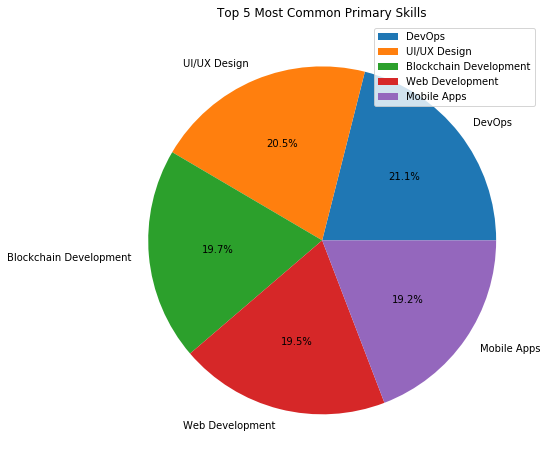

In [36]:
#What are the top 5 skills in use?
Top_Paying_Skills=df.groupby("primary_skill")["primary_skill"].count().sort_values(ascending=False).head(5)
Top_Paying_Skills
#pie chart 
plt.figure(figsize=(8, 8))
plt.pie(Top_Paying_Skills, autopct='%1.1f%%',labels=Top_Paying_Skills.index)
plt.title("Top 5 Most Common Primary Skills")
plt.legend()
plt.show()

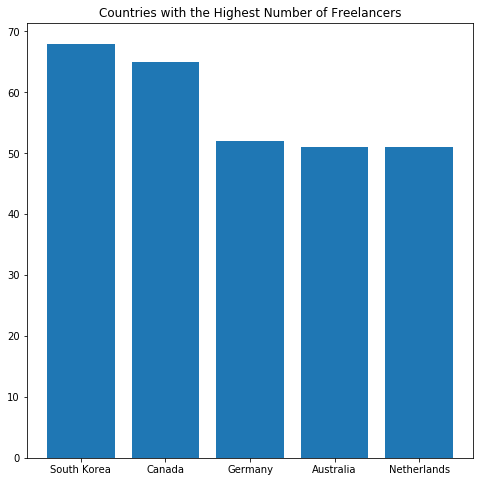

In [44]:
# Which country has the highest number of freelancers
max_freelancers_country_wise=df.groupby("country")["country"].count().sort_values(ascending=False).head(5)
max_freelancers_country_wise
plt.figure(figsize=(8,8))
plt.bar(max_freelancers_country_wise.index,max_freelancers_country_wise.values)
plt.title("Countries with the Highest Number of Freelancers")
plt.show()

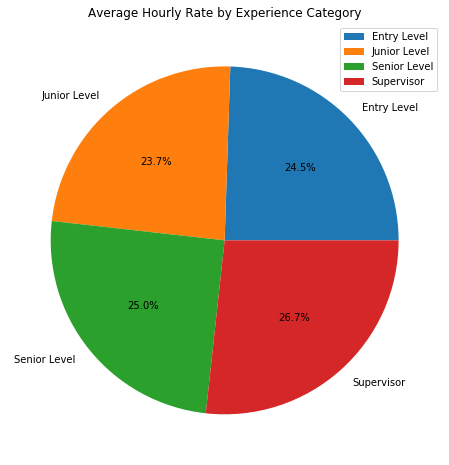

In [54]:
#Does experience significantly influence freelancer earnings?
def age_category(n):
    if n<5:
        return "Entry Level"
    elif n>5 and n<10:
        return "Junior Level"
    elif n>10 and n<20:
        return "Senior Level"
    else:
        return "Supervisor"

df["Category_YOE"]=df["years_of_experience"].apply(age_category)
freelancer_earnings_YOE_wise=df.groupby("Category_YOE")["hourly_rate (USD)"].mean()

#plotting a pie chart 
plt.figure(figsize=(8,8))
plt.pie(freelancer_earnings_YOE_wise,labels=freelancer_earnings_YOE_wise.index,autopct='%1.1f%%')
plt.title("Average Hourly Rate by Experience Category")
plt.legend()
plt.show()

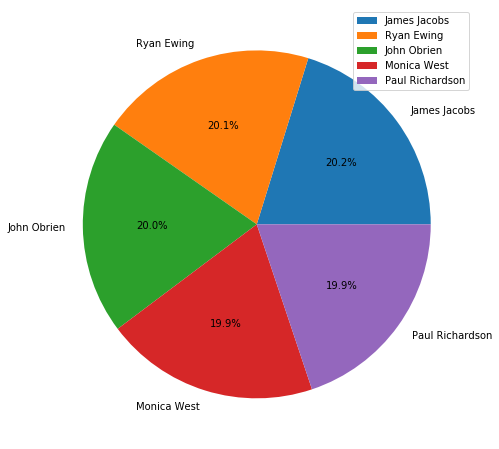

In [51]:
#5. Who are the top-performing freelancers based on a composite performance score?
# Composite Score based on this: 30%_rating, 30% client_satisfaction, 20%_experience, 20% hourly_rate
s= lambda x : x["rating"]*0.3 + x["client_satisfaction"]*0.3 + x["years_of_experience"]*0.2 + x["hourly_rate (USD)"]*0.2
df["Composite_Category"]=df.apply(s,axis=1)
Top_performing=df.nlargest(5,"Composite_Category")
Top_performing[["name","Composite_Category"]]
plt.figure(figsize=(8,8))
plt.pie(Top_performing["Composite_Category"],autopct="%1.1f%%",labels=Top_performing["name"])
plt.legend()
plt.show()

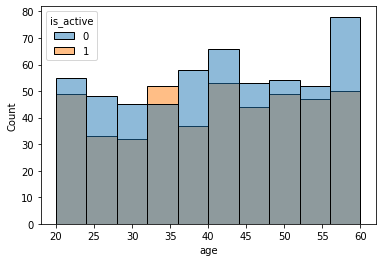

In [59]:
# does the age influence the number of people which are inactive 
sns.histplot(x=df["age"],hue=df["is_active"],bins=10)

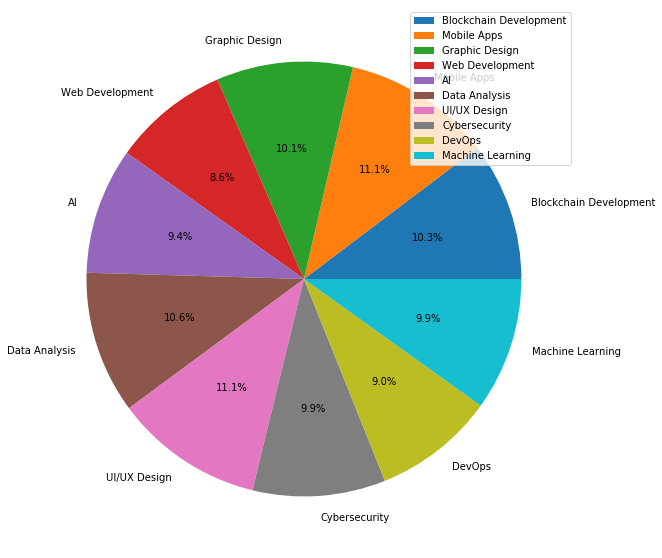

In [57]:
# to find out how many percentage of people are active in a particular category 
a=df.groupby("primary_skill")["is_active"].mean()*100
plt.figure(figsize=(10,10))
plt.pie(a,labels=df["primary_skill"].unique(),autopct="%1.1f%%")
plt.legend()
plt.show()

In [23]:
a=df.select_dtypes(include=np.number)
a

,age,years_of_experience,hourly_rate (USD),rating,is_active,client_satisfaction,Composite_Category
0,52.0,11.0,100.0,2.51257,0,79.269417,46.734596
1,52.0,34.0,100.0,3.30000,1,84.000000,52.990000
2,53.0,31.0,50.0,0.00000,0,71.000000,37.500000
3,38.0,4.0,40.0,1.50000,0,90.000000,36.250000
4,53.0,27.0,30.0,4.80000,0,83.000000,37.740000
...,...,...,...,...,...,...,...
995,56.0,13.0,100.0,0.00000,0,68.000000,43.000000
996,26.0,6.0,40.0,2.80000,0,82.000000,34.640000
997,37.0,15.0,75.0,2.51257,0,94.000000,46.953771
998,46.0,22.0,100.0,2.80000,1,97.000000,54.340000


In [24]:
df.columns

Index(['freelancer_ID', 'name', 'gender', 'age', 'country', 'language',
       'primary_skill', 'years_of_experience', 'hourly_rate (USD)', 'rating',
       'is_active', 'client_satisfaction', 'Category_YOE',
       'Composite_Category'],
      dtype='object')

In [25]:
numeric_df = print(pd.__version__)
print(np.__version__)

1.3.5
1.21.6


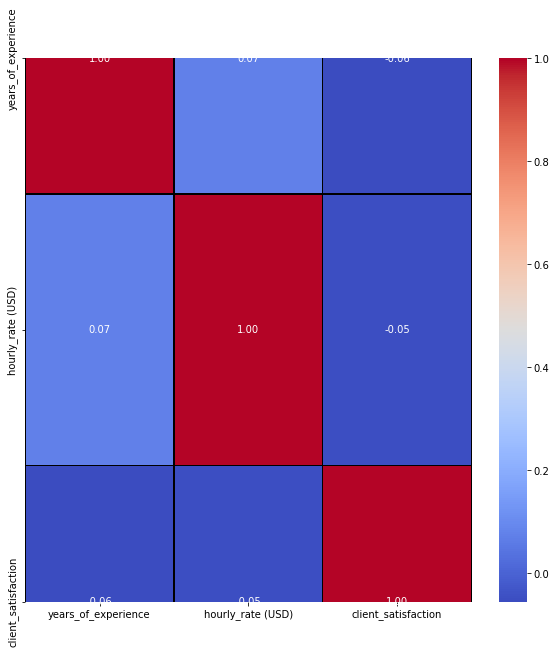

In [26]:
#the heatmap visualizing the correlation among experience, hourly rate, and client satisfaction.
df1=df[["years_of_experience","hourly_rate (USD)","client_satisfaction"]]
df_corr=df1.corr()
df_corr
plt.figure(figsize=(10,10))
sns.heatmap(df_corr,annot=True,cmap="coolwarm",linecolor="black",linewidth=0.4,fmt="0.2f")